<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/Tutorial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# This will open a file picker to upload your CSV file
uploaded = files.upload()
# Necessary Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Loading Dataframe
df = pd.read_csv("Iris.csv")

# Dataset Information
print("Dataset Preview:")
print(df.head())
print("\nDataset Information")
print(df.info())

Saving Iris.csv to Iris.csv
Dataset Preview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(

In [2]:
# Step 3: Extract features (X) and target labels (y)
X = df.iloc[:, 1:-1].values  # All columns except first (index) and last (target)
y = df.iloc[:, -1].values    # Last column (target)

# Step 4: Convert categorical labels to numeric
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Convert labels to integers (0,1,2)

# Step 5: One-Hot Encode the Labels
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Display results
print("\nUnique Classes:", np.unique(y))
print("Encoded Labels:", np.unique(y_encoded))
print("One-Hot Encoded Labels:\n", y_one_hot[:5])  # Show first 5


Unique Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded Labels: [0 1 2]
One-Hot Encoded Labels:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [3]:
# Step 6: Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_one_hot, test_size=0.2, random_state=42, stratify=y_one_hot
)

# Output shapes
print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Shapes:
X_train: (120, 4) y_train: (120, 3)
X_test: (30, 4) y_test: (30, 3)


In [4]:
import numpy as np

def softmax(z):
    """
    Compute softmax probabilities for a given input matrix.
    Parameters:
        z: Logits (raw scores) of shape (m, n)
           - m is the number of samples
           - n is the number of classes
    Returns:
        Softmax probability matrix of shape (m, n)
    """
    # Prevent numerical instability by normalizing input
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [5]:
def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss.
    Parameters:
        y_pred: Predicted probabilities of shape (n, c)
        y: True labels (one-hot encoded) of shape (n, c)
    Returns:
        float: Cross-entropy loss
    """
    epsilon = 1e-12  # To avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)  # Prevent log(0)
    n = y.shape[0]  # Number of samples
    loss = -np.sum(y * np.log(y_pred)) / n
    return loss

In [6]:
def cost_softmax(X, y, W, b):
    """
    Compute the softmax regression cost (cross-entropy loss).
    Parameters:
        X: Feature matrix of shape (n, d)
        y: True labels (one-hot encoded) of shape (n, c)
        W: Weight matrix of shape (d, c)
        b: Bias vector of shape (c,)
    Returns:
        float: The softmax cost (cross-entropy loss)
    """
    n = X.shape[0]  # Number of samples
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    cost = loss_softmax(y_pred, y)
    return cost

In [7]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function w.r.t weights and biases.
    Parameters:
        X: Feature matrix of shape (n, d)
        y: True labels (one-hot encoded) of shape (n, c)
        W: Weight matrix of shape (d, c)
        b: Bias vector of shape (c,)
    Returns:
        tuple: Gradients w.r.t weights (d, c) and biases (c,)
    """
    n, d = X.shape
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n  # Gradient w.r.t weights
    grad_b = np.sum(y_pred - y, axis=0) / n  # Gradient w.r.t biases
    return grad_W, grad_b

In [8]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize weights and biases.
    Parameters:
        X: Feature matrix (n, d)
        y: True labels one-hot encoded (n, c)
        W: Weight matrix (d, c)
        b: Bias vector (c,)
        alpha: Learning rate
        n_iter: Number of iterations
        show_cost: Whether to display cost at intervals
    Returns:
        tuple: Optimized weights, biases, and cost history
    """
    cost_history = []
    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Update weights and biases
        W -= alpha * grad_W
        b -= alpha * grad_b

        # Compute and store cost
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        # Print cost at regular intervals
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

In [9]:
def predict_softmax(X, W, b):
    """
    Predict class labels using the trained softmax model.
    Parameters:
        X: Feature matrix (n, d)
        W: Weight matrix (d, c)
        b: Bias vector (c,)
    Returns:
        Predicted class labels of shape (n,)
    """
    z = np.dot(X, W) + b       # Compute scores (logits)
    y_pred = softmax(z)         # Get probabilities

    # Assign the class with the highest probability
    predicted_classes = np.argmax(y_pred, axis=1)
    return predicted_classes

Iteration 0: Cost = 1.024689
Iteration 100: Cost = 0.474027
Iteration 200: Cost = 0.265790
Iteration 300: Cost = 0.222742
Iteration 400: Cost = 0.195346
Iteration 500: Cost = 0.176190
Iteration 600: Cost = 0.161999
Iteration 700: Cost = 0.151035
Iteration 800: Cost = 0.142292
Iteration 900: Cost = 0.135144
Iteration 999: Cost = 0.129236


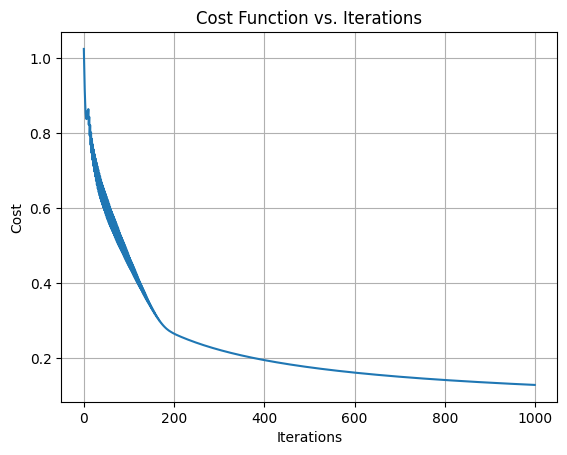

In [11]:
import matplotlib.pyplot as plt

# Initialize weights and biases
d = X_train.shape[1]  # Number of features
c = y_train.shape[1]  # Number of classes
W = np.random.randn(d, c) * 0.01  # Small random weights
b = np.zeros(c)                    # Bias initialized to 0

# Set hyperparameters
alpha = 0.1    # Learning rate
n_iter = 1000  # Number of iterations

# Train the model
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot cost history
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


In [12]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    """
    Evaluate using confusion matrix, precision, recall, F1-score.
    """
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Predict on test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# True labels in numeric form
y_test_labels = np.argmax(y_test, axis=1)

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print results
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Precision: 0.97
Recall:    0.97
F1-Score:  0.97
